# Packages

In [25]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')
geomodel_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Geological_Models'))
geophysical_dir = os.path.abspath(os.path.join(BASE_DIR, '..', '..', 'Data', 'Input_Data', 'Geophysical_Cleaned_Data'))

trigger_create_cross_section = True

# Model Parameters

In [26]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Plutonite dip angle
plutonite_dip_angle = 70 # 70

# Importing Plutonic Model

In [27]:
# --- Load full model ---
with open(os.path.join(geomodel_dir, 'Plutonite-Basement_Models', 'plutonite_geo_model.pkl'), "rb") as f:
    plutonite_geo_model = pickle.load(f)

# Forward Modelling Gravity

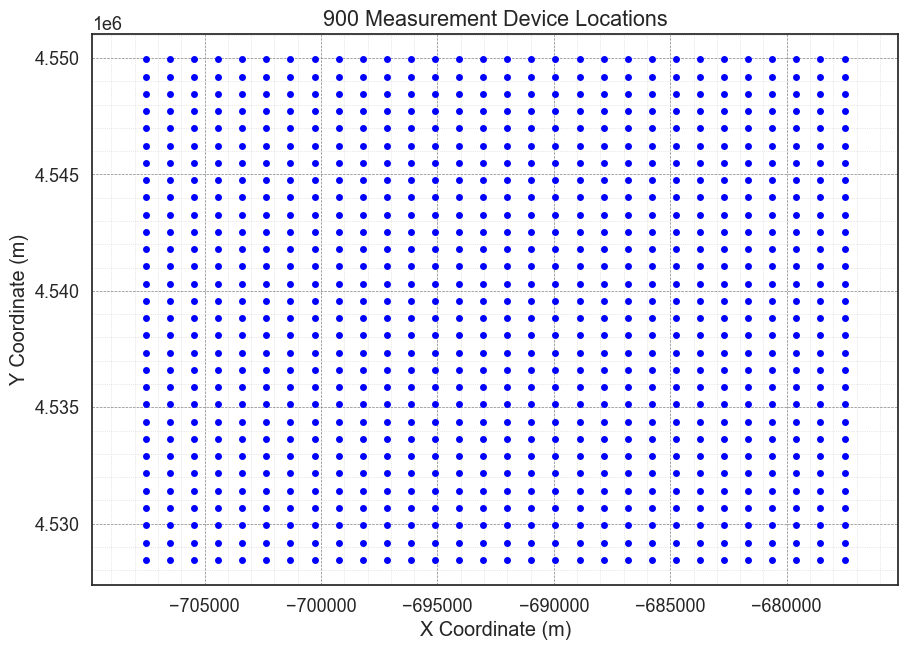

Active grids: GridTypes.NONE|CENTERED|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 700 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


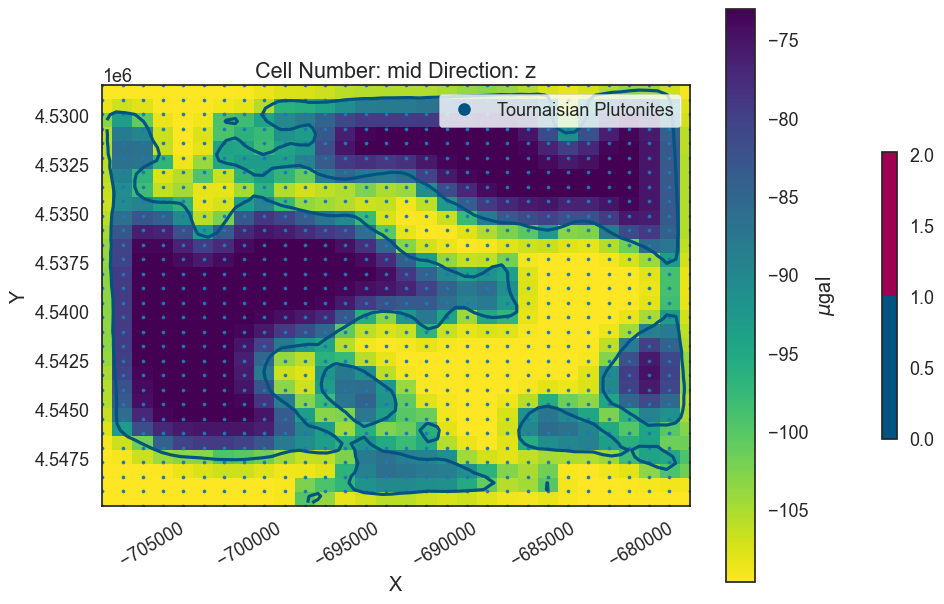

array([-109.60567874, -109.60567874, -109.60567874, -109.60567874,
       -109.60567874, -109.60567874, -109.60567874, -109.60567874,
       -109.60567874, -109.14255208,  -99.82965575, -103.61259491,
       -108.18300329, -107.13642403, -105.8616972 , -105.8616972 ,
       -106.87350438, -107.38125727, -106.87350438, -107.76269457,
       -108.74018089, -108.8949474 , -108.23896835, -109.12940495,
       -109.60567874, -109.60567874, -109.60567874, -109.60363284,
       -109.56987635, -109.56938722, -109.60567874, -109.60567874,
       -109.60567874, -109.60567874, -109.60567874, -109.60567874,
       -109.60567874, -109.60567874, -109.60567874, -109.29150399,
       -102.3298269 ,  -99.19804653,  -97.08083303,  -91.84037227,
        -90.30727745,  -90.30727745,  -91.07534029,  -91.45893497,
        -95.46017235, -100.92937737, -105.51360841, -104.51067529,
       -100.12175559, -108.97770946, -109.60567874, -109.59416777,
       -109.32263335, -109.08252959, -108.78803651, -108.93309

In [28]:
from forward_modelling_gravity import Forward_Modelling_Gravity

Forward_Modelling_Gravity(gempy_model = plutonite_geo_model, densities = np.array([2, 3]), grav_res = 30, extent = extent,
                          resolution = [5,5,10], radius = [1000,1000,1000], visualise_measurement_locations=True,
                          visualise_forward_results=True, field_measurement_locations = [])

# Misfit Calculation with QGIS Gravity Data

In [29]:
# Importing cleaned gravity data
gravity_data = gpd.read_file(os.path.join(geophysical_dir, 'cleaned_gravity_data.geojson'))

# Create measurement points at gravity data locations
gravity_measurement_points = np.column_stack([
    np.array(gravity_data.geometry.x.values),
    np.array(gravity_data.geometry.y.values),
    np.full(len(gravity_data), max_z)  # Set Z to surface elevation
])

# Observed gravity values
observed_gravity = gravity_data['VALU_BOU267'].values # in mGal

grav_res is ignored


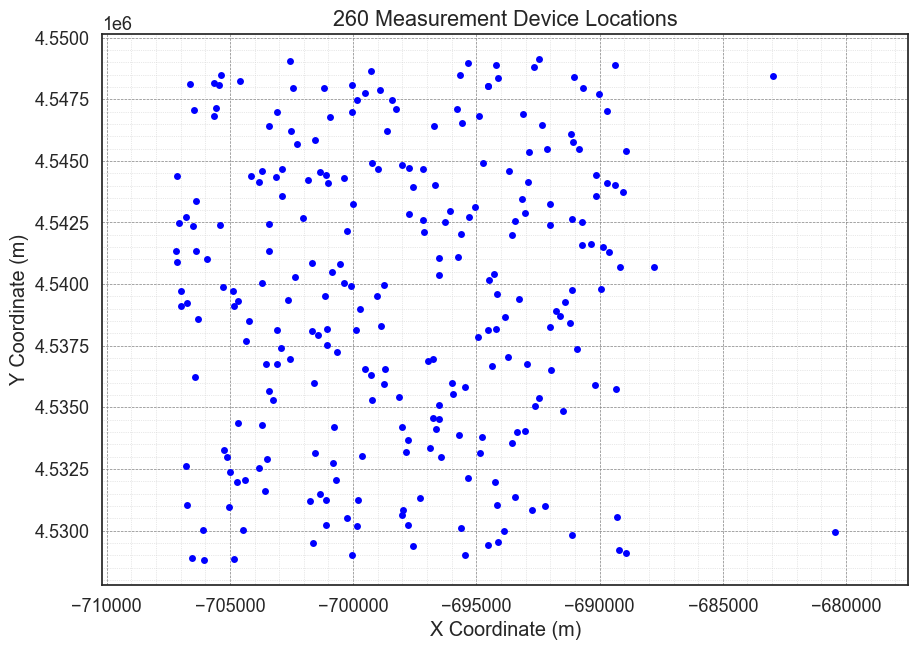

Active grids: GridTypes.NONE|CENTERED|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 466 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


In [30]:
gravity = Forward_Modelling_Gravity(gempy_model = plutonite_geo_model, densities = np.array([2, 3]), grav_res = 10, extent = extent,
                          resolution = [5,5,10], radius = [1000,1000,1000], visualise_measurement_locations=True,
                          visualise_forward_results=True, field_measurement_locations=gravity_measurement_points)

Gravity Misfit Analysis:
  Mean Misfit: 0.126 mGal
  Std Misfit: 0.435 mGal
  Min Residual: -0.818 mGal
  Max Residual: 0.873 mGal


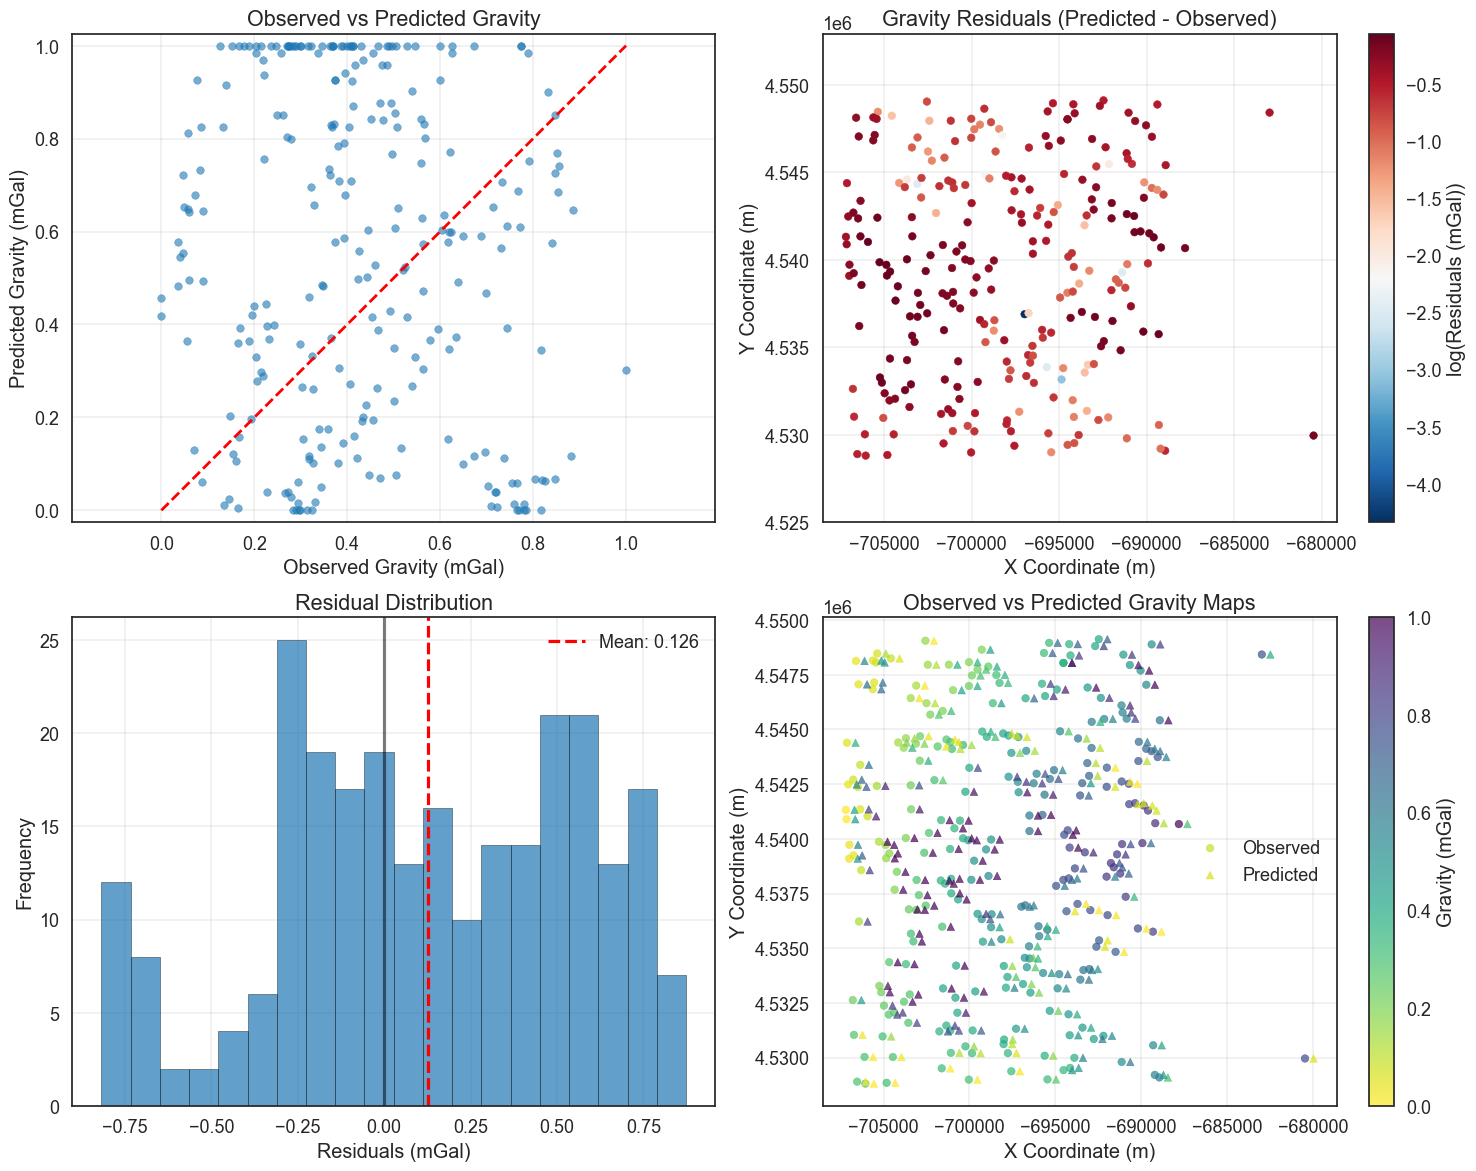

In [31]:
import misfit

normalised_gravity = (gravity - np.min(gravity)) / (np.max(gravity) - np.min(gravity))
normalised_observed_gravity = (observed_gravity - np.min(observed_gravity)) / (np.max(observed_gravity) - np.min(observed_gravity))

misfit_value = misfit.misfit_geophysical(observed_data = normalised_observed_gravity, modelled_data = normalised_gravity, error_formula='MSE')

resisuals = misfit.plot_residuals(observed_data = normalised_observed_gravity, modelled_data = normalised_gravity, field_measurement_locations = gravity_measurement_points)